In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("data/mental_health.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (53043, 3)


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52681 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  52681 non-null  int64 
 1   statement   52681 non-null  object
 2   status      52681 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


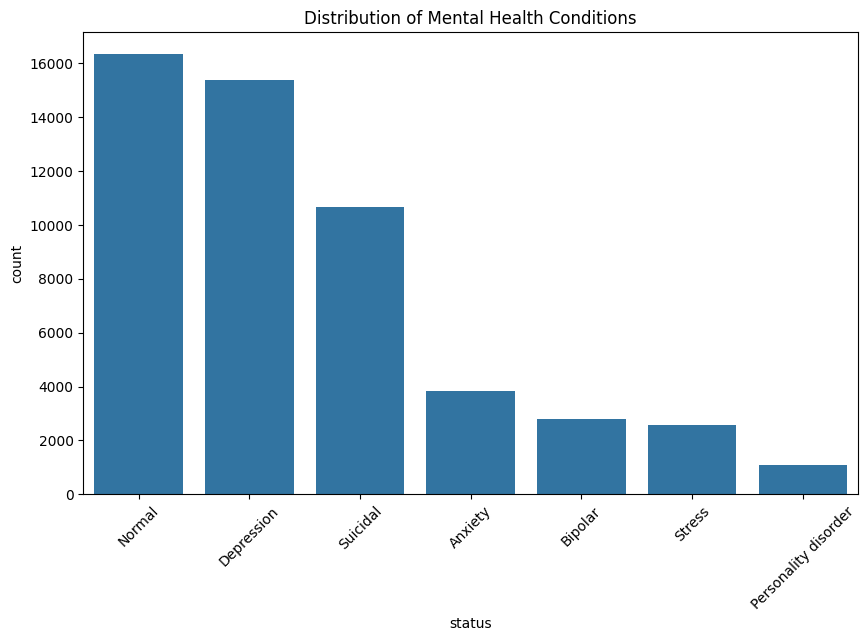

In [8]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="status",
    order=df["status"].value_counts().index
)

plt.title("Distribution of Mental Health Conditions")
plt.xticks(rotation=45)
plt.show()

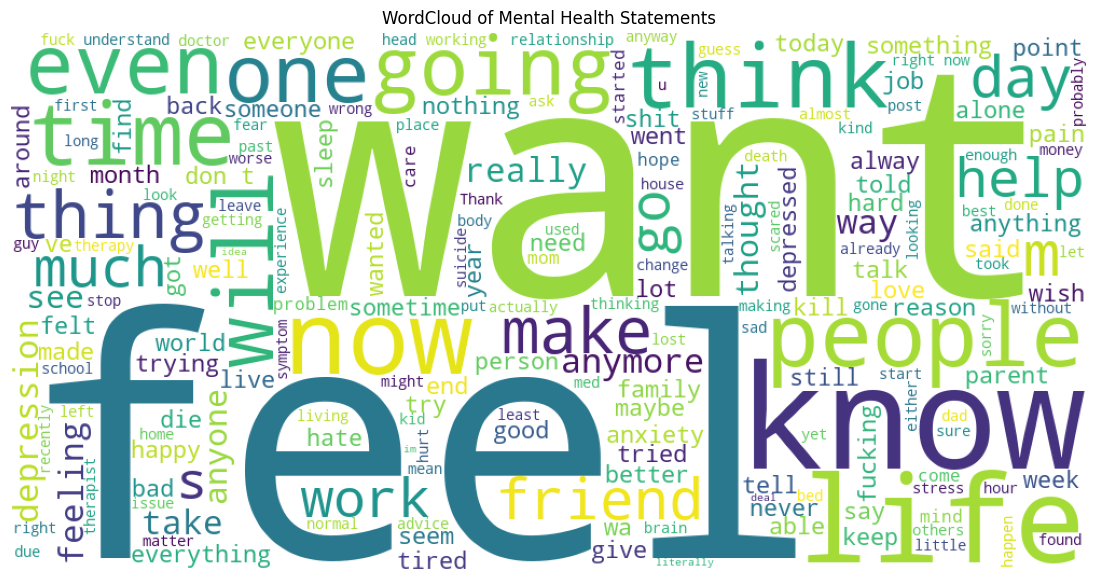

In [10]:
text = " ".join(df["statement"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud of Mental Health Statements")

plt.show()

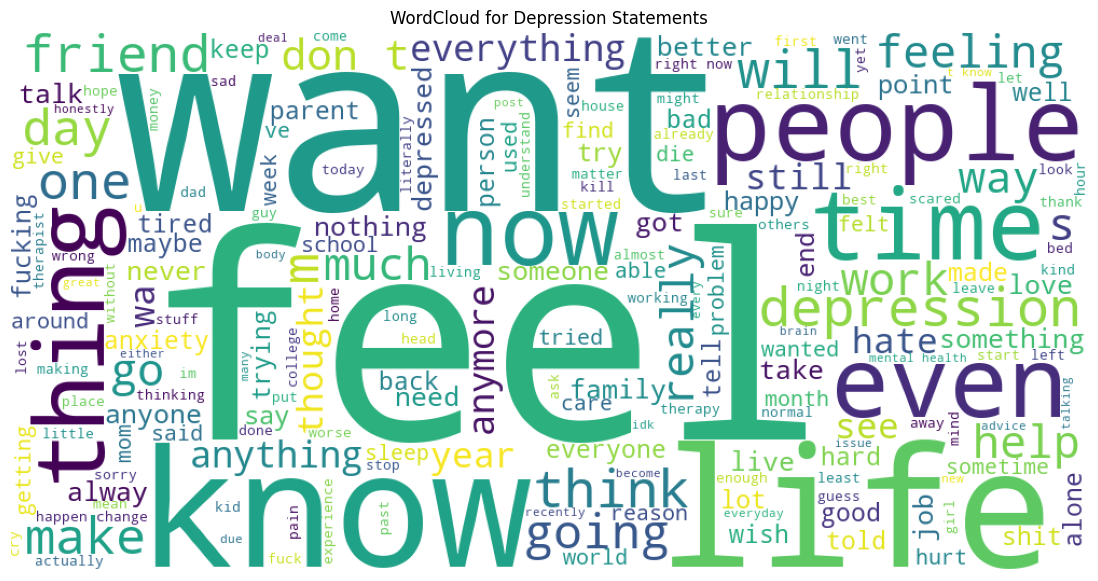

In [11]:
depression_text = " ".join(
    df[df["status"] == "Depression"]["statement"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(depression_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud for Depression Statements")

plt.show()

In [12]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["statement"])

y = df["status"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [16]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy: {:.2f}%".format(nb_accuracy*100))

Naive Bayes Accuracy: 66.49%


In [17]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy: {:.2f}%".format(svm_accuracy*100))

C:\Users\ranir\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


SVM Accuracy: 77.71%


In [18]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy: {:.2f}%".format(rf_accuracy*100))

Random Forest Accuracy: 70.04%


In [20]:
print("Classification Report (SVM Model):")

print(classification_report(y_test, svm_pred))

Classification Report (SVM Model):
                      precision    recall  f1-score   support

             Anxiety       0.80      0.79      0.80       941
             Bipolar       0.85      0.75      0.80       669
          Depression       0.72      0.71      0.72      3792
              Normal       0.88      0.95      0.91      4130
Personality disorder       0.83      0.56      0.67       280
              Stress       0.70      0.53      0.60       654
            Suicidal       0.68      0.68      0.68      2705

            accuracy                           0.78     13171
           macro avg       0.78      0.71      0.74     13171
        weighted avg       0.77      0.78      0.77     13171



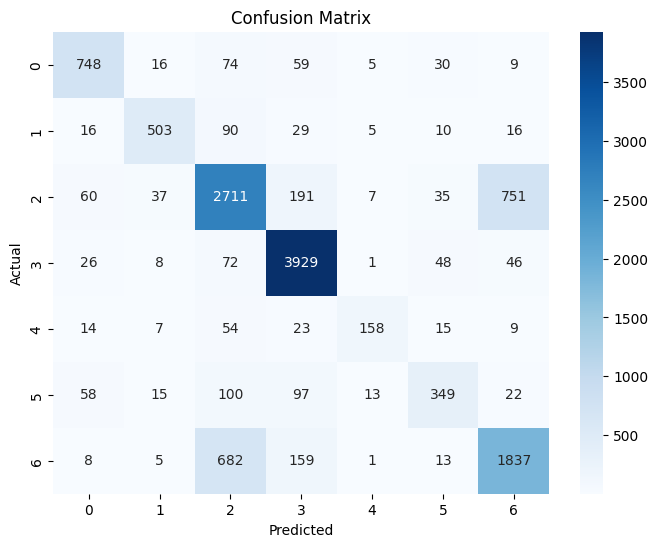

In [21]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

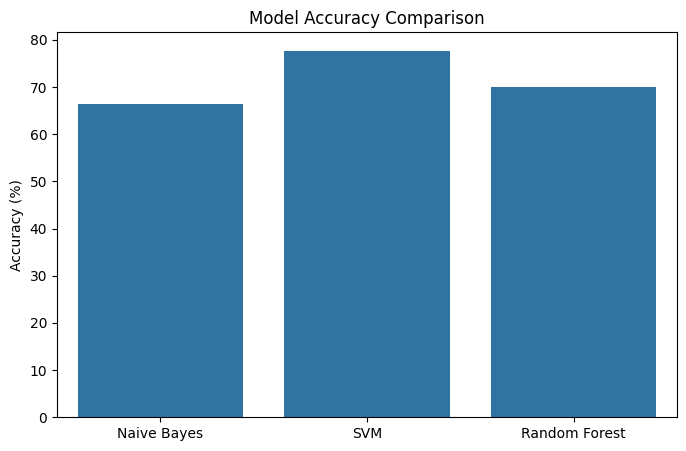

In [22]:
models = ["Naive Bayes", "SVM", "Random Forest"]

accuracies = [
    nb_accuracy*100,
    svm_accuracy*100,
    rf_accuracy*100
]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

In [23]:
sample_text = ["I feel very lonely and depressed"]

sample_vector = vectorizer.transform(sample_text)

prediction = svm_model.predict(sample_vector)

print("Predicted Mental Health Status:", prediction[0])

Predicted Mental Health Status: Depression
